### **[A]: Choice of a population, with supporting expenditure data**

In [1]:
!pip install -r requirements.txt

In [2]:
#Importing
%pip install python-gnupg
%pip install eep153_tools
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [15]:
#Prices
ugd5_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2010-11).csv')
ugd5_p0 = ugd5_p0[ugd5_p0["u"] == "Kg"]
ugd5_p = pd.pivot_table(ugd5_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd5_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2010-11).csv')
ugd5_x0['i'] = ugd5_x0['i'].astype(str)
ugd5_x = pd.pivot_table(ugd5_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd5_x_long = ugd5_x.stack().reset_index(name="Expenditure")
ugd5_p_long = ugd5_p0
ugd5_c = ugd5_x_long.merge(ugd5_p_long, on=["j", "t", "m"], how="left")
ugd5_c["Consumption"] = ugd5_c["Expenditure"] / ugd5_c["price"]
ugd5_c = ugd5_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z0 = pd.read_csv('Data Files/Uganda - Household Characteristics.csv')
ugd5_z = ugd_z0[ugd_z0['t'] == '2010-11']
ugd5_z = ugd5_z.set_index(['i','t','m'])
ugd5_z.columns.name = 'k'
ugd5_z.fillna(0, inplace=True)

### **[B]: Nutritional content of different foods**

In [16]:
#FCT
ugd_fct = pd.read_csv('Data Files/Uganda - FCT.csv')
ugd_fct = ugd_fct.rename(columns={"index":"j"}).set_index(["j"])
ugd_fct.columns.name = 'n'
#RDI
ugd_rdi = pd.read_csv('Data Files/Uganda - RDA.csv')
ugd_rdi = ugd_rdi.set_index(["n"])
ugd_rdi.columns.name = 'k'

### **[A]: Estimate demand system**

In [20]:
import cfe
from cfe import Regression

ugd5_result = cfe.Regression(y=np.log(ugd5_x.stack()),d=ugd5_z)

In [21]:
ugd5_result.predicted_expenditures()

i           t        m        j            
1013000201  2010-11  Central  Avocado          1774.777035
                              Beans (dry)      3600.513774
                              Beans (fresh)    3790.986185
                              Beef             7472.254266
                              Bread            2700.578385
                                                  ...     
4193003510  2010-11  Western  Sorghum          7019.209173
                              Sugar            6036.802496
                              Sweet Bananas    4101.899795
                              Tea               831.590084
                              Tomatoes         2215.058523
Length: 84952, dtype: float64

<Axes: xlabel='yhat', ylabel='y'>

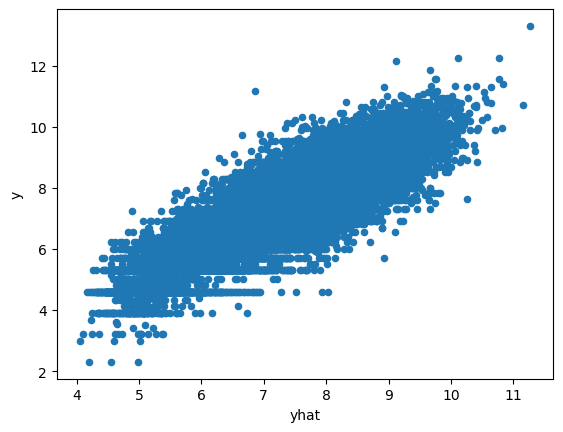

In [22]:
#Expenditures x may have duplicate columns
x1 = ugd5_x0.groupby(['i','t','m','j']).sum()
#Replace zeros with missing values
x1 = x1.replace(0,np.nan)
#Take logs of expenditures; call this y
y = np.log(x1["Expenditure"])
#Create dataframe with predicted yhat values
ugd5_acc = pd.DataFrame({'y':y,'yhat':ugd5_result.get_predicted_log_expenditures()})
#Plot yhat vs y (predicted vs actual)
ugd5_acc.plot.scatter(x='yhat',y='y')

In [24]:
ugd5_result.R2(summary=True)

0.7645283116281243

In [26]:
#Save result
ugd5_result.to_pickle('./Uganda10-11.rgsn')
##To access result:
#import cfe
#result = cfe.regression.read_pickle('Uganda10-11.rgsn')

### Parameters

**(Relative) Income Elasticity:** $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.
Here we use a plot to visualize, with confidence intervals.

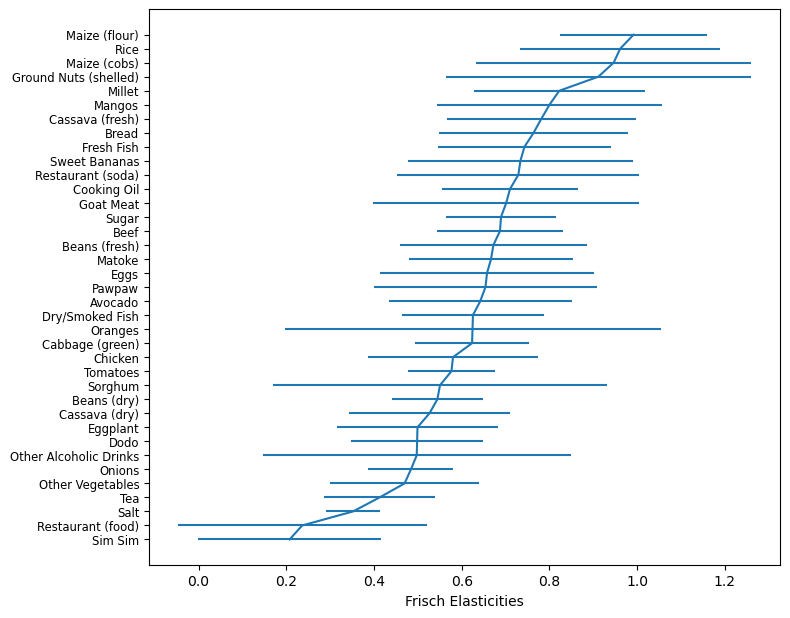

In [27]:
ax1 = ugd5_result.graph_beta()

In [28]:
ugd5_result.get_beta().sort_values(ascending=False)

j
Maize (flour)             0.991901
Rice                      0.961312
Maize (cobs)              0.946415
Ground Nuts (shelled)     0.911380
Millet                    0.822446
Mangos                    0.800049
Cassava (fresh)           0.781538
Bread                     0.763776
Fresh Fish                0.743035
Sweet Bananas             0.733775
Restaurant (soda)         0.729093
Cooking Oil               0.710099
Goat Meat                 0.701405
Sugar                     0.689623
Beef                      0.687263
Beans (fresh)             0.672242
Matoke                    0.666799
Eggs                      0.657683
Pawpaw                    0.654162
Avocado                   0.642297
Dry/Smoked Fish           0.625570
Oranges                   0.624637
Cabbage (green)           0.623544
Chicken                   0.580090
Tomatoes                  0.576543
Sorghum                   0.550504
Beans (dry)               0.544450
Cassava (dry)             0.526541
Eggplant          

**Demand and Household Composition:** $\gamma_j$ parameters in the regression, which capture the effects of household composition on demand

In [29]:
ugd5_result.get_gamma()

k,F 00-03,M 00-03,F 04-08,M 04-08,F 09-13,M 09-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,
Avocado,-0.093932,-0.081884,-0.054118,-0.004630,0.000763,-0.042467,-0.007887,-0.205203,-0.049395,0.041322,0.022023,-0.013573,-0.004821,-0.119526,0.642296,6.942435
Beans (dry),0.008361,0.103370,0.090024,0.136113,0.018721,0.056150,0.099265,-0.043257,0.073250,0.105171,0.075847,0.082068,0.153477,0.146246,-0.022533,8.017704
Beans (fresh),-0.039524,0.069552,0.067102,-0.073059,-0.040521,0.055505,0.054035,0.051738,0.013884,0.064019,0.009836,0.103003,0.193784,0.297372,0.400990,7.975434
Beef,0.009488,0.011957,0.048695,0.028764,0.046637,0.058025,0.025537,0.035762,0.030461,0.068526,0.098232,0.109888,0.147396,0.150096,-0.001470,8.718932
Bread,0.019600,0.024691,-0.001408,0.150399,0.121394,0.022599,0.000202,-0.019938,-0.154029,0.041784,0.023770,0.138727,0.104680,0.074277,0.057352,7.628436
Cabbage (green),0.009588,-0.004797,0.048700,0.024470,0.027037,0.035171,0.110451,-0.060649,0.018781,0.037639,0.081483,0.064100,0.000720,-0.008703,0.119487,6.752120
Cassava (dry),0.043567,0.035205,-0.005260,0.033181,-0.141649,-0.130565,-0.060312,0.102459,0.070080,0.031007,0.046992,-0.031101,-0.016288,0.117954,0.516868,8.206270
Cassava (fresh),-0.032581,0.093548,0.130494,0.080686,0.048882,0.007661,0.036429,-0.068237,0.104542,0.148541,0.122345,0.087269,0.168031,0.228808,0.093962,7.795316
Chicken,0.006898,-0.013124,0.027999,0.006737,0.050944,-0.034673,-0.169327,-0.025726,-0.068097,0.013073,0.017699,0.103366,0.084389,0.148624,0.185667,9.070176


**Welfare:** $w_i$ parameters, which are a welfare measure for the household.

<Axes: ylabel='Density'>

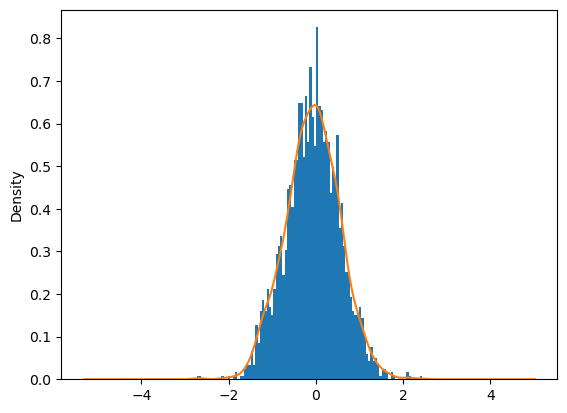

In [30]:
ax2 = ugd5_result.get_w().plot.hist(bins=100,density=True)
ugd5_result.get_w().plot.kde(ax=ax2)

### Demand and Utility

**Budgets:** Get food budget for all households, then find median budget

In [31]:
xhat = ugd5_result.predicted_expenditures()
#Total food expenditures per household
xbar = xhat.groupby(['i','t','m']).sum()
#Reference budget
xref = xbar.quantile(0.5)  # Household at 0.5 quantile is median

**Reference Prices:** Choose reference prices.  Here we chose the year 2015 and averaged prices across markets.

In [32]:
#Prices per kilogram:
pbar = ugd5_p.mean(axis=1)
pbar = pbar.reset_index(level="u", drop=True) #Reset index so that 'j' becomes a column instead of part of a MultiIndex
pbar = pbar.reindex(ugd5_result.beta.index) #Only use prices for goods we can estimate
#Replace missing prices with 1 (this is because they're best measured in expenditures)
pbar = pbar.replace(np.nan,1)
#Define a function to change a single price in the vector $p$:
def my_prices(p0,j,p=pbar):
    """
    Change price of jth good to p0, holding other prices fixed.
    """
    p = p.copy()
    p.loc[j] = p0
    return p

**Demand as a function of prices:** Demand schedules for households with different budgets

Text(0.5, 0, 'Quantities of Beef Demanded')

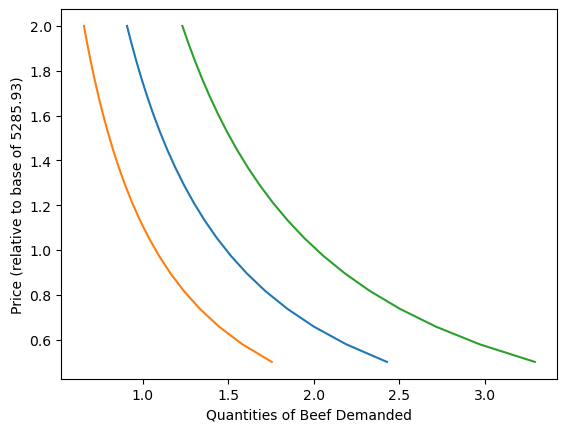

In [33]:
use = 'Beef'  #Good we want demand curve for

#Vary prices from 50% to 200% of reference.
scale = np.linspace(.5,2,20)

#Demand for Millet for household at median budget
plt.plot([ugd5_result.demands(xref,my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 25% percentile
plt.plot([ugd5_result.demands(xbar.quantile(0.25),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 75% percentile
plt.plot([ugd5_result.demands(xbar.quantile(0.75),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

plt.ylabel(f"Price (relative to base of {pbar[use]:.2f})")
plt.xlabel(f"Quantities of {use} Demanded")

**Engel Curves:** Tracing how demand changes with budget

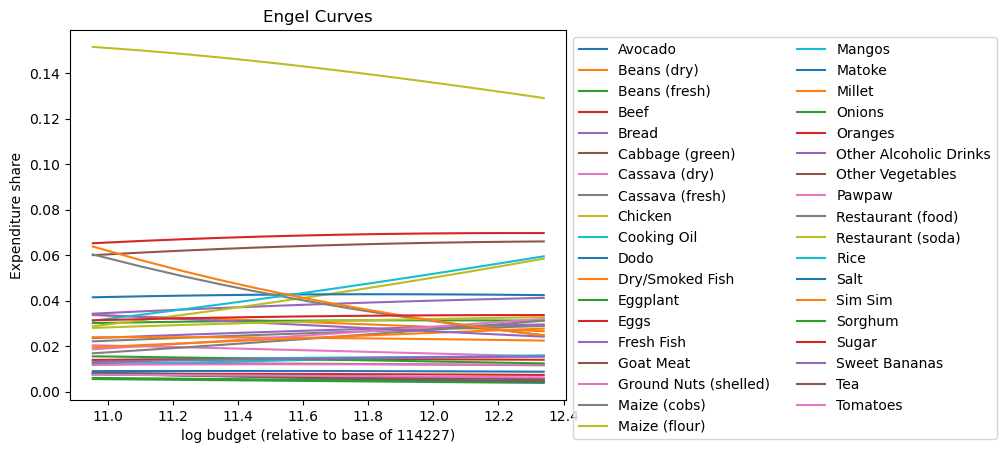

In [35]:
fig,ax = plt.subplots()

ax.plot(np.log(scale*xref),[ugd5_result.expenditures(s*xref,pbar)/(s*xref) for s in scale])
ax.set_xlabel(f'log budget (relative to base of {xref:.0f})')
ax.set_ylabel(f'Expenditure share')
ax.set_title('Engel Curves')
ax.legend(ugd5_result.expenditures(xref,pbar).index.tolist(), loc="upper left", bbox_to_anchor=(1, 1), ncol=2)

**Indirect Utility Function:**

Text(0.5, 1.0, 'Indirect Utility Function')

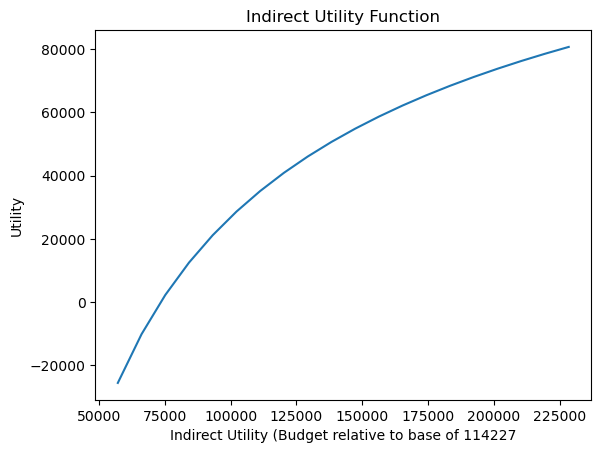

In [36]:
fig,ax = plt.subplots()

ax.plot(scale*xref,[ugd5_result.indirect_utility(s*xref,pbar) for s in scale])
ax.set_xlabel(f'Indirect Utility (Budget relative to base of {xref:.0f}')
ax.set_ylabel(f'Utility')
ax.set_title('Indirect Utility Function')

### **[B]: Nutritional adequacy of diet**

In [37]:
#Get result saved above
ugd5_result = cfe.read_pickle('Uganda10-11.rgsn')
#Quantities in kg: expenditures divided by prices/kg
qhat = (xhat.unstack('j')/ugd5_p.reset_index(drop=True, level="u").transpose()).dropna(how='all')
#Drop missing columns
qhat = qhat.loc[:,qhat.count()>0]

In [38]:
#Columns of qhat to match fct
use = ugd_fct.index.intersection(qhat.columns)

nutrients = qhat[use]@ugd_fct.loc[use,:]
nutrients.mean()    # NB: Nutrients are for past /week/ for entire household

n
Energy          161658.271908
Protein           6912.867683
Fiber             2631.523199
Folate           37016.004551
Calcium          24006.233908
Carbohydrate     26747.242154
Iron              1092.437953
Niacin            1588.530711
Riboflavin          91.754531
Thiamin            125.485128
Vitamin A        11671.844955
Vitamin B-12       349.275746
Vitamin B-6        243.281720
Vitamin C        13421.011060
Zinc               643.521169
Magnesium            0.000000
Phosphorus           0.000000
Potassium            5.563817
Vitamin E            0.000000
Vitamin K            0.000000
dtype: float64

In [39]:
#Obtain recommended daily intake
ugd5_z = ugd5_z[ugd_rdi.columns.tolist()]
hh_rdi = ugd5_z@ugd_rdi.T
#Make this a recommended WEEKLY intake
hh_rwi = hh_rdi*7
# Match up nutrient names
use_nutrients = nutrients.columns.intersection(hh_rwi.columns)
nutrient_ratio = (nutrients[use_nutrients]/hh_rwi[use_nutrients]).dropna()
#Display
nutrient_ratio

,,n,Energy,Protein,Fiber,Folate,Calcium,Carbohydrate,Iron,Niacin,Riboflavin,Thiamin,Vitamin A,Vitamin B-12,Vitamin B-6,Vitamin C,Zinc,Magnesium,Phosphorus,Potassium,Vitamin E,Vitamin K
i,t,m,,,,,,,,,,,,,,,,,,,,
1013000201,2010-11,Central,1.611042,3.332087,1.876888,2.126363,0.458764,3.796719,1.945230,2.376896,1.833654,2.225136,0.332173,3.659361,3.950311,3.051034,1.499106,0.0,0.0,0.000031,0.0,0.0
1013000204,2010-11,Central,2.496073,6.046425,2.912432,3.343778,0.552428,3.838812,3.055623,3.547676,2.906159,3.570649,0.565376,5.444654,5.887032,6.194533,2.791189,0.0,0.0,0.000040,0.0,0.0
1021000108,2010-11,Central,1.656143,3.512494,1.879820,2.196598,0.451872,3.542298,2.281702,2.433226,1.841014,2.265315,0.315650,4.062178,3.806121,2.797680,1.417791,0.0,0.0,0.000030,0.0,0.0
1021000109,2010-11,Central,2.689075,5.998030,3.049861,3.744009,0.697134,5.635159,3.909539,4.102908,3.150978,3.962244,0.549565,6.342538,7.140376,5.241525,2.565799,0.0,0.0,0.000043,0.0,0.0
1021000111,2010-11,Central,1.583610,3.307998,1.793537,1.812760,0.421290,3.349707,1.504169,2.302497,1.693395,2.023448,0.292315,3.849170,3.546798,2.584637,1.413946,0.0,0.0,0.000027,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4193003504,2010-11,Western,1.901751,4.348918,2.528596,2.770985,0.416778,4.075046,1.815800,2.898850,2.149970,2.753757,0.321654,4.381551,4.920594,3.580914,1.799602,0.0,0.0,0.000025,0.0,0.0
4193003506,2010-11,Western,1.990331,4.301048,2.634689,2.917277,0.380336,4.156569,2.292328,2.783463,2.224348,3.057942,0.324838,4.155331,5.083351,3.614634,1.928057,0.0,0.0,0.000017,0.0,0.0
4193003508,2010-11,Western,1.572186,3.879702,2.075855,2.549915,0.364924,3.214670,2.175865,2.515396,1.937004,2.281395,0.314101,4.247045,3.988546,2.830741,1.495739,0.0,0.0,0.000019,0.0,0.0


<Axes: >

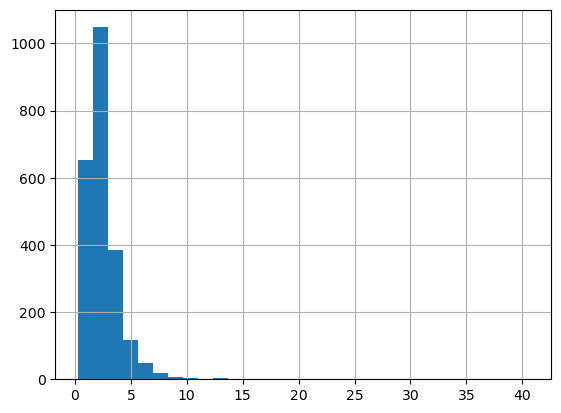

In [40]:
#Plot nutrient ratio for specific nutrient
%matplotlib inline
nutrient_ratio['Energy'].hist(bins=30)